In [1]:
import librosa
import numpy as np
import os
import pickle
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

C:\Users\bhave\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# feature extraction

In [2]:

def extract_features(audio_path, n_mfcc=13):
    """
    Extract MFCC features from an audio file.
    """
    y, sr = librosa.load(audio_path, duration=5, sr=16000)  # Load 5 seconds at 16 kHz
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)  # Extract 13 MFCCs
    return np.mean(mfccs.T, axis=0)

In [3]:
def prepare_data(directory):
    """
    Prepare datasets by extracting features and assigning labels.
    """
    features = []
    labels = []
    
    for label, sub_dir in enumerate(['real', 'fake']):  # 'real' -> 0, 'fake' -> 1
        full_path = os.path.join(directory, sub_dir)
        for file_name in os.listdir(full_path):
            file_path = os.path.join(full_path, file_name)
            mfcc_features = extract_features(file_path)
            features.append(mfcc_features)
            labels.append(label)
    
    return np.array(features), np.array(labels)

In [4]:
# Extract features
X, y = prepare_data('C:/Users/bhave/Downloads/datasets/audio/data')

In [5]:
mfcc_feature_names = [f'mfcc{i+1}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=mfcc_feature_names)
df['label'] = y

In [6]:
df.head()

,mfcc1,mfcc2,mfcc3,mfcc4,mfcc5,mfcc6,mfcc7,mfcc8,mfcc9,mfcc10,mfcc11,mfcc12,mfcc13,label
0,-215.706451,52.993282,17.912443,-9.326214,-20.341400,-21.087446,-10.850847,-14.115512,-14.423497,-11.589069,-16.774761,-5.126242,-15.564522,0
1,-211.724030,45.614456,15.039762,-17.228735,-10.232596,-8.463048,-17.680357,-10.992297,-15.128969,-7.900747,-14.308885,-4.700095,-13.796829,0
2,-220.825134,50.147591,14.786477,-11.551631,-5.611121,-11.125587,-8.496225,-23.007765,-13.690757,-9.082284,-19.107857,-0.542767,-14.572453,0
3,-223.927689,46.918282,14.998158,-14.261194,-10.029119,-10.725889,-9.215972,-15.541698,-14.821897,-11.263863,-19.739220,0.405017,-15.775717,0
4,-236.704025,62.483795,8.799322,-13.946179,-12.938197,-12.501881,-9.335881,-15.348478,-11.615202,-10.711686,-17.997498,-3.142642,-15.707140,0


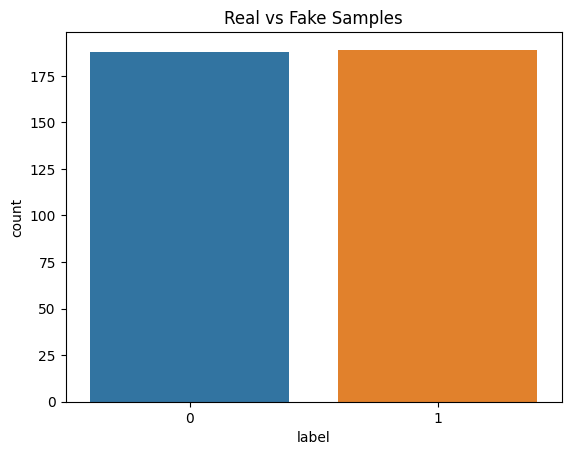

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# EDA: Plot class distribution
sns.countplot(x='label', data=df)
plt.title("Real vs Fake Samples")
plt.show()


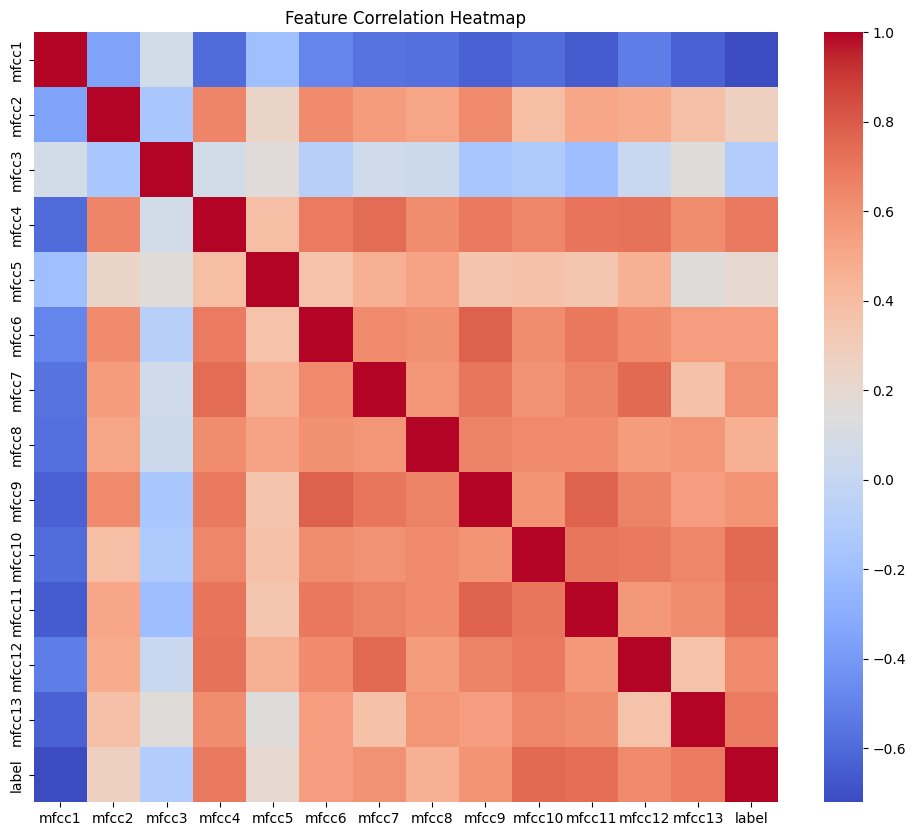

In [8]:
# EDA: Correlation Matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

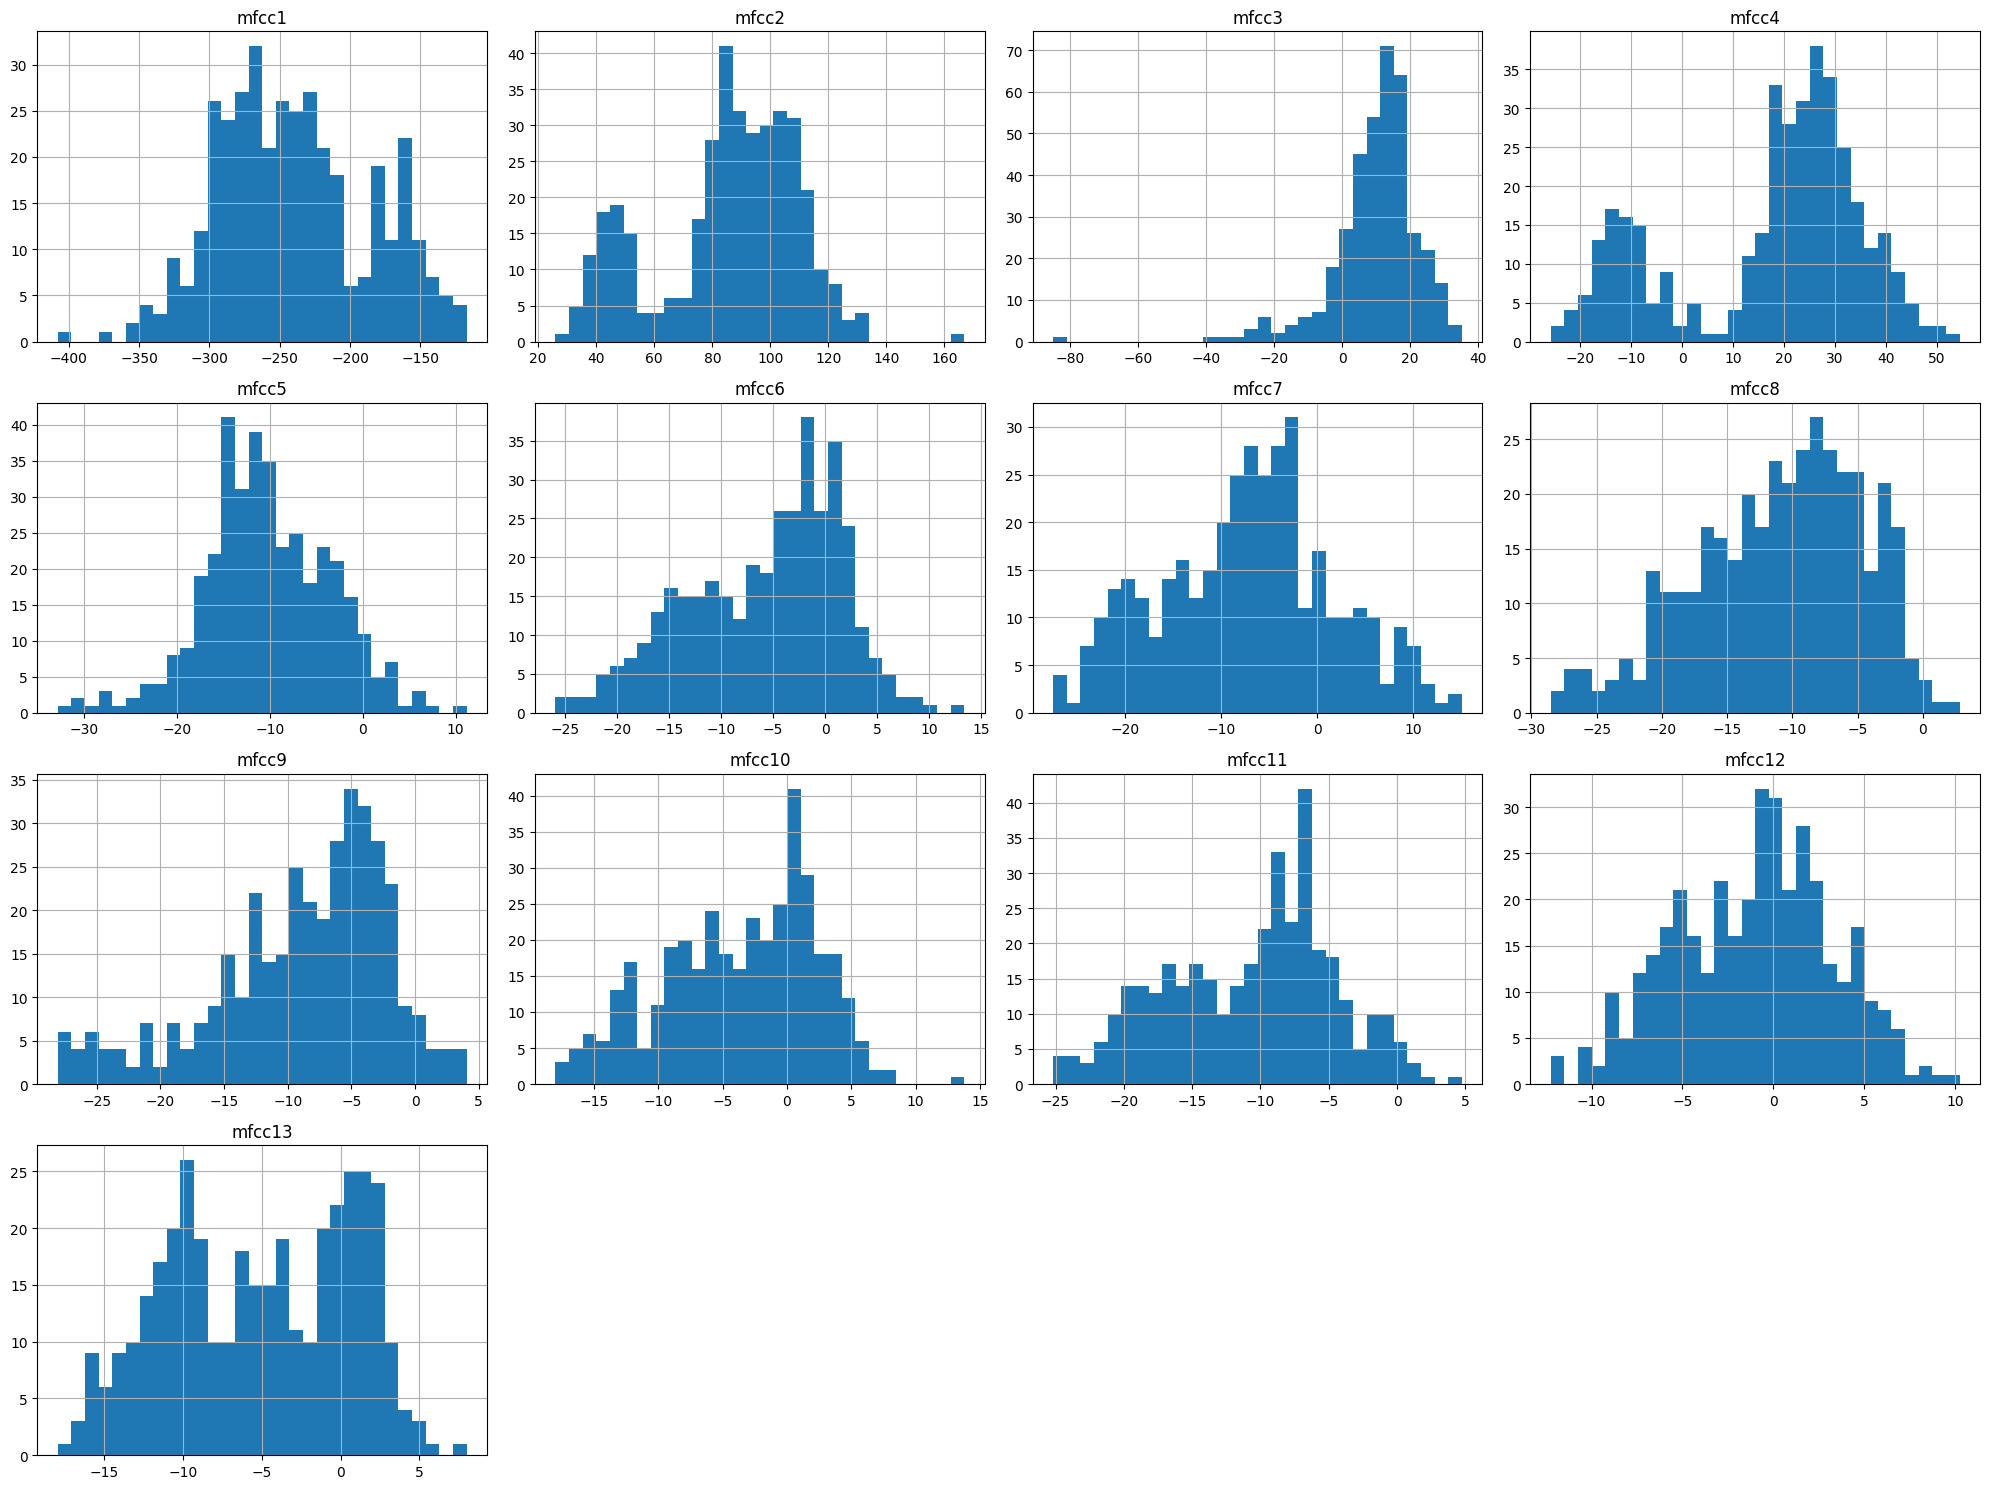

In [9]:

# EDA: Feature Distribution
df.drop('label', axis=1).hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

# data cleaning 

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

def clean_data(features, labels):
    """
    Simplifies data cleaning by handling missing values, normalizing features, and shuffling the data.
    :param features: NumPy array of feature vectors
    :param labels: NumPy array of labels
    :return: Cleaned and shuffled features and labels
    """
    print("Starting data cleaning...")

    # Remove rows with missing values (NaN)
    mask = ~np.isnan(features).any(axis=1)
    features = features[mask]
    labels = labels[mask]
    print(f"Samples after removing missing values: {features.shape[0]}")

    # Normalize features using StandardScaler
    scaler = StandardScaler()
    features = scaler.fit_transform(features)
    print("Features normalized.")
    
    with open("scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    

    # Shuffle the dataset
    features, labels = shuffle(features, labels, random_state=42)
    print("Data shuffled.")

    return features, labels

# Example usage
try:
    X_cleaned, y_cleaned = clean_data(X, y)
    print(f"Cleaned data: {X_cleaned.shape[0]} samples, {X_cleaned.shape[1]} features")
except Exception as e:
    print(f"Error during cleaning: {e}")


Starting data cleaning...
Samples after removing missing values: 377
Features normalized.
Data shuffled.
Cleaned data: 377 samples, 13 features


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)


# logistic reg

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score,recall_score,f1_score,precision_score
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [13]:
pred_test_log = logreg.predict(X_test)
pred_test_log

array([0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1])

In [14]:
tab_log = confusion_matrix(y_test, pred_test_log)
tab_log

array([[36,  1],
       [ 0, 39]], dtype=int64)

# decision Tree

In [18]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [19]:
pred_dt = dt.predict(X_test)
pred_dt

array([0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1])

In [20]:
tab_dt = confusion_matrix(y_test, pred_dt)
tab_dt

array([[34,  3],
       [ 0, 39]], dtype=int64)

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        37
           1       0.93      1.00      0.96        39

    accuracy                           0.96        76
   macro avg       0.96      0.96      0.96        76
weighted avg       0.96      0.96      0.96        76




# random forest

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate the model
y_pred = rf.predict(X_test)

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score,recall_score,f1_score,precision_score
tab = confusion_matrix(y_test, y_pred)
tab

array([[36,  1],
       [ 0, 39]], dtype=int64)

In [25]:
 print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        37
           1       0.97      1.00      0.99        39

    accuracy                           0.99        76
   macro avg       0.99      0.99      0.99        76
weighted avg       0.99      0.99      0.99        76



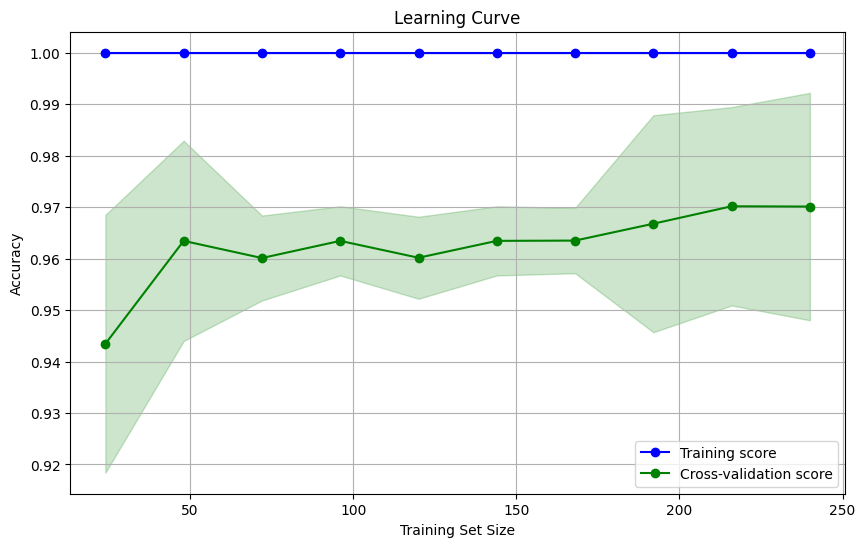

In [30]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(rf, X, y, cv=5, scoring='accuracy'):
    train_sizes, train_scores, val_scores = learning_curve(rf, X, y, cv=cv, scoring=scoring, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=42)

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', color='green', label='Cross-validation score')

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='green')

    plt.title('Learning Curve')
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid()
    plt.show()

# Usage:
plot_learning_curve(rf, X_train, y_train, cv=5)


# cross validation

In [34]:
from sklearn.model_selection import cross_val_score

models = [logreg, dt, rf]

model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

# Empty list for results
results = []

# Loop
for name, model in zip(model_names, models):
    val_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_accuracy = np.mean(val_scores)
    std_accuracy = np.std(val_scores)
    
    results.append({
        "Model": name,
        "Mean Accuracy": mean_accuracy,
        "Standard Deviation": std_accuracy
    })

results_df = pd.DataFrame(results)


In [35]:
results_df

,Model,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.963443,0.019456
1,Decision Tree,0.916940,0.027894
2,Random Forest,0.970109,0.016309


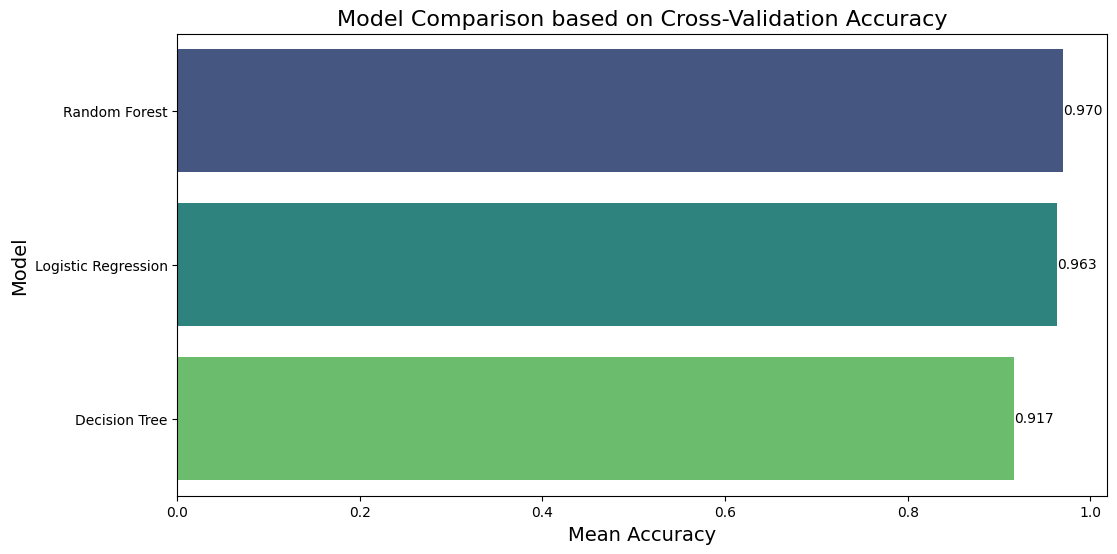

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the models by Mean Accuracy (optional but looks good)
results_df = results_df.sort_values(by='Mean Accuracy', ascending=False)

# Set figure size
plt.figure(figsize=(12,6))

# Create barplot
sns.barplot(x='Mean Accuracy', y='Model', data=results_df, palette='viridis')

# Titles and labels
plt.title('Model Comparison based on Cross-Validation Accuracy', fontsize=16)
plt.xlabel('Mean Accuracy', fontsize=14)
plt.ylabel('Model', fontsize=14)

# Show accuracy values on the bars
for index, value in enumerate(results_df['Mean Accuracy']):
    plt.text(value, index, f"{value:.3f}", va='center')

plt.show()


In [37]:
import pickle
pickle_out = open("audio_deepfake_model.pkl","wb")
pickle.dump(model, pickle_out)
pickle_out.close()